# Visualize JAX Function Samplers

This notebook demonstrates how to use and visualize the JAX-based function samplers defined in your project.

## 1. Setup and Imports

Import necessary libraries and configure the path to your project source code. We also enable `autoreload` so that changes made to your `.py` files are automatically picked up when you re-run cells.

In [91]:
%load_ext autoreload
%autoreload 2

import jax 
jax.config.update('jax_enable_checks', False)
import sys
import os
# import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple, Tuple, Dict, List
import jax.experimental.checkify as checkify # Import checkify


# IMPORTANT: Set this to the correct root directory of your project
# Use an absolute path for reliability
root_dir = r"c:\Users\jimvo\Documents\Recurrent-PPO-Jax" # Use the path you provided

if not os.path.isdir(root_dir):
    print(f"Error: Directory not found: {root_dir}")
    print("Please update the 'root_dir' variable to the correct path.")
else:
    if root_dir not in sys.path:
        sys.path.append(root_dir)
        print(f"Added {root_dir} to sys.path")

# Attempt to import your sampler functions
try:
    # Assuming your functions are in this specific module path
    from src.tasks.envs.jax_env_f.jax_function_samplers import (
        initialize_sampler,
        compute_y_sampler,
        
        # Also import EnvParams if it's defined there, otherwise define it below
        EnvParams
    )
    
    print("Successfully imported sampler functions.")
except ImportError as e:
    print(f"Error importing sampler functions: {e}")
    print("Please ensure 'root_dir' is correct and the module path exists:")
    print("src.tasks.envs.function_envs.jax_samplers.jax_function_samplers")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")

# --- Define EnvParams if not imported ---
# (Make sure this matches the definition expected by your functions)
# class EnvParams(NamedTuple):
#     action_dim: int
#     x_range: Tuple[float, float]
#     # Add other default parameters needed by your initializers
#     poly_degree: int = 2
#     poly_c_bounds: Tuple[float, float] = (5.0, 20.0)
#     poly_weight_bounds: Tuple[float, float] = (0.5, 2.0)
#     poly_optimum_range_factor: float = 0.9
#     ackley_a_bounds: Tuple[float, float] = (15.0, 20.0)
#     ackley_b_bounds: Tuple[float, float] = (0.1, 0.2)
#     ackley_c_bounds: Tuple[float, float] = (2 * jnp.pi, 2 * jnp.pi)
#     ackley_optimum_range_factor: float = 0.6

# Configure Matplotlib for inline plotting
# %matplotlib inline
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.style.use('seaborn-v0_8-darkgrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Successfully imported sampler functions.


## 2. Visualize a Single Sampled Function (1D)

Let's initialize one instance of a function (e.g., Polynomial, index 1) and plot it. We'll focus on 1D functions (`action_dim=1`) for easy visualization.

--- Initialized Sampler Parameters ---


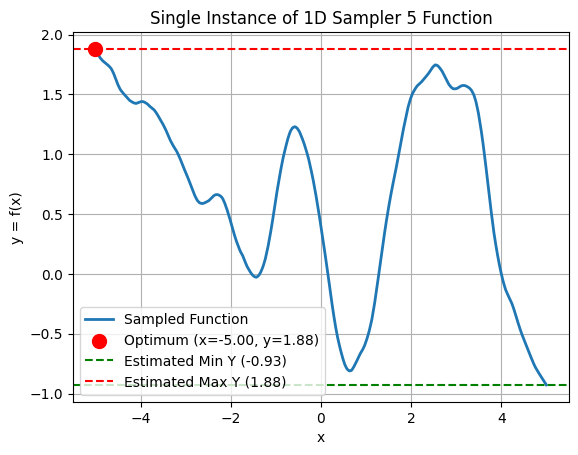

In [96]:
# --- Configuration ---
sampler_index_to_plot = 5  # 0 for Ackley, 1 for Polynomial
action_dimension = 1
x_min, x_max = -5.0, 5.0
num_points = 500 # Number of points for plotting the function shape


sample_dict = {'common': {
            'type_index': sampler_index_to_plot, # Assuming Ackley is index 0
            'optimum_point': 0,
            'max_y': 0,
            'min_y': 0,
            'action_dim': action_dimension,
        },
        'specific': {
            'ackley': {
                "a": 15.0,
                "b": 0.1,
                "c": 2 * np.pi,
                'optimum_range_factor': 0.9,
                'a_bounds': (15.0, 20.0),
                'b_bounds': (0.1, 0.2),
                'c_bounds': (2 * np.pi, 2 * np.pi),
            },
            'poly' :{
                'c': 10.0,
                'weights': jnp.full((action_dimension,), jnp.nan), # Dummy Array
                'x_max': jnp.full((action_dimension,), jnp.nan),   # Dummy Array
                'degree': 2,
                'optimum_range_factor': 0.9,
                'c_bounds': (5.0, 20.0),
                'weight_bounds': (0.5, 2.0),
                'steepness_factor': 1.0,
                'steepness_factor': 10.0,
                'steep_min': 0.5,
                'steep_max': 2.0,
                
            },
            'neg_abs': {},
            'gaussian': {
                'center': jnp.full((action_dimension,), jnp.nan),
                'width': jnp.full((action_dimension,), jnp.nan),
                'amplitude': 1.0,
                'baseline': 1.0,
                'width_bounds': (1.0,2.0),
                'amplitude_bounds': (0.5, 2.0),
                'baseline_bounds': (0.5, 2.0),
            },
            'matern52': {
                'grid_size': 200,
                'x_grid': jnp.full((200), jnp.nan),
                'y_grids': jnp.full((action_dimension, 200), jnp.nan),
            },
        }
}

# --- Environment Parameters ---
# env_params = EnvParams(action_dim=action_dimension, x_range=(x_min, x_max), )
env_params = EnvParams(total_samples=5, max_batches=1, max_steps_in_episode=20, sampler_configs=sample_dict)


# --- Initialize Sampler ---
key = jax.random.PRNGKey(0) # Use a fixed key for reproducibility
# print("Key:", key, key.shape)
# functionalized_checker = checkify.checkify(initialize_sampler,
#                                            errors=checkify.float_checks)

# # 2. JIT the functionalized wrapper, making action_dim static
# jitted_checker = jax.jit(functionalized_checker, static_argnames=('action_dim',))

# # 3. Call the jitted, functionalized function
# #    >>> Double-check: Ensure 'action_dimension' is <class 'int'> <<<
# key = jax.random.PRNGKey(0)
# sampler_index_to_plot = 1
# action_dimension = 5  # MUST be <class 'int'>
# # env_params = ...    # Your EnvParams object

# try:
#     print("Attempting call with outer JIT + checkify (no inner JITs)...")
#     err, out = jitted_checker(key, sampler_index_to_plot, action_dimension, env_params)
#     print("Call succeeded!")
#     # if err.is_error(): err.throw() # Optional: check errors
# except Exception as e:
#     print(f"Call failed with error: {type(e).__name__}")
#     print(e) # Print the error message - which one is it now?


sampler_params = initialize_sampler(key, sampler_index_to_plot, action_dimension, env_params) #this line still crashes

print("--- Initialized Sampler Parameters ---")
# Pretty print the dictionary contents
# for k, v in sampler_params.items():
#     print(f"  {k}: {v}")

# --- Generate Data for Plotting ---
# Create a range of x values for plotting
x_plot = jnp.linspace(x_min, x_max, num_points).reshape(-1, action_dimension)
# x_plot = jnp.expand_dims(x_plot, axis=0)  # Add a batch dimension


# # Compute y values using vmap for efficiency
# # Define a function that computes y for a single x using the initialized params
compute_single_y_jit = jax.jit(lambda x: compute_y_sampler(x, sampler_params, env_params))
# Map the JITted function over all x values
y_plot = jax.vmap(compute_single_y_jit, in_axes=0)(x_plot)

compute_batch_y = jax.vmap(lambda x: compute_y_sampler(x, sampler_params, env_params))

# JIT the whole vmapped operation
compute_batch_y_jit = jax.jit(compute_batch_y)

y_plot = compute_batch_y_jit(x_plot)

# --- Plotting ---
plt.figure()
plt.plot(x_plot.flatten(), y_plot.flatten(), label='Sampled Function', linewidth=2)

# Highlight Min/Max and Optimum
# for k in sampler_params.keys():
#     print(k["commmon"])

opt_x = sampler_params["common"]['optimum_point']
max_y = sampler_params["common"]['max_y']
min_y = sampler_params["common"]['min_y']

plt.scatter([opt_x], [max_y], color='red', s=100, zorder=5, label=f'Optimum (x={opt_x[0]:.2f}, y={max_y:.2f})')
plt.axhline(min_y, color='green', linestyle='--', label=f'Estimated Min Y ({min_y:.2f})')
plt.axhline(max_y, color='red', linestyle='--', label=f'Estimated Max Y ({max_y:.2f})')

# Add labels and title
func_name = 'Polynomial' if sampler_index_to_plot == 1 else 'Ackley' if sampler_index_to_plot == 0 else f'Sampler {sampler_index_to_plot}'
plt.title(f'Single Instance of 1D {func_name} Function')
plt.xlabel('x')
plt.ylabel('y = f(x)')
plt.legend()
plt.grid(True)
plt.show()

In [93]:
sampler_index_to_plot = 4  # 0 for Ackley, 1 for Polynomial


## 3. Visualize Multiple Sampled Functions (1D)

Now, let's sample multiple functions (e.g., 5 Ackley functions, index 0) and plot them on the same graph to see the variety generated by the sampler.

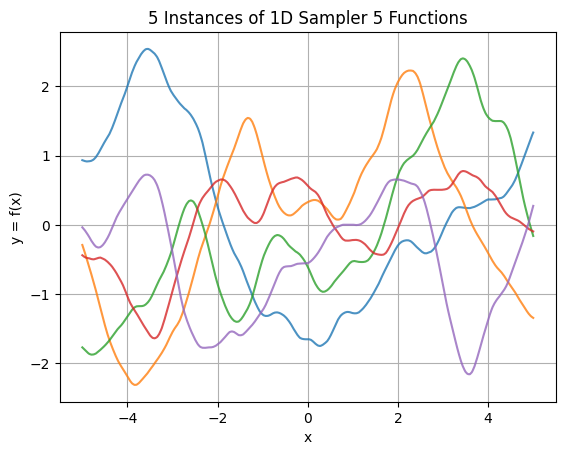

In [99]:
# --- Configuration ---
sampler_index_to_plot = 5  # 0 for Ackley, 1 for Polynomial
num_functions_to_plot = 5
action_dimension = 1
x_min, x_max = -5.0, 5.0
num_points = 500 # Number of points for plotting the function shape

sample_dict['specific']['poly'] = {
                'c': 10.0,
                'weights': jnp.full((action_dimension,), jnp.nan), # Dummy Array
                'x_max': jnp.full((action_dimension,), jnp.nan),   # Dummy Array
                'degree': 2,
                'optimum_range_factor': 0.9,
                'c_bounds': (0.0, 10.0),
                'weight_bounds': (0.5, 10.0),
                'steepness_factor': 10.0,
                'steep_min': 0.5,
                'steep_max': 1.5,
                
            }

sample_dict['specific']['gaussian'] = {
                'center': jnp.full((action_dimension,), jnp.nan),
                'width': jnp.full((action_dimension,), jnp.nan),
                'amplitude': 1.0,
                'baseline': 1.0,
                'width_bounds': (0.3,1.0),
                'amplitude_bounds': (0.5, 2.0),
                'baseline_bounds': (0.5, 2.0),
}
                

sample_dict['common']['bounds'] = sampler_index_to_plot # Assuming Ackley is index 0

# --- Environment Parameters ---
env_params = EnvParams(total_samples=5, max_batches=1, max_steps_in_episode=20, sampler_configs=sample_dict)
# --- Generate Data for Plotting ---
key = jax.random.PRNGKey(99) # Starting key

b = 5.0
x_min = -b
x_max = b

x_plot = jnp.linspace(x_min, x_max, num_points).reshape(-1, action_dimension)

plt.figure()

for i in range(num_functions_to_plot):
    # Get a new key for each function instance
    key, subkey = jax.random.split(key)

    # Initialize the sampler
    sampler_params = initialize_sampler(subkey, sampler_index_to_plot, action_dimension, env_params)

    # Compute y values for this specific function instance
    compute_single_y = lambda x: compute_y_sampler(x, sampler_params, env_params)
    y_plot = jax.vmap(compute_single_y)(x_plot)

    # Plot this function instance
    plt.plot(x_plot.flatten(), y_plot.flatten(), label=f'Instance {i+1}', alpha=0.8)

# Add labels and title
func_name = 'Polynomial' if sampler_index_to_plot == 1 else 'Ackley' if sampler_index_to_plot == 0 else f'Sampler {sampler_index_to_plot}'
plt.title(f'{num_functions_to_plot} Instances of 1D {func_name} Functions')
plt.xlabel('x')
plt.ylabel('y = f(x)')
# plt.legend() # Legend might get crowded, optional
plt.grid(True)
plt.show()

## 4. Notes on 2D Visualization (Optional)

Visualizing 2D functions (`action_dim=2`) requires different plotting techniques:

1.  **Create a grid:** Use `jnp.meshgrid` to create X and Y coordinate matrices over the `x_range`.
2.  **Combine coordinates:** Stack the X and Y matrices to form input points `(x, y)` suitable for `compute_y_sampler` (shape `(num_points*num_points, 2)`).
3.  **Compute Z values:** Calculate the function output `Z` for all points on the grid.
4.  **Reshape Z:** Reshape the output `Z` back into a 2D grid matching the X and Y shapes.
5.  **Plot:** Use `plt.contourf` (filled contour) or `plt.imshow` (image plot) to visualize the 2D function landscape. You can also add the optimum point using `plt.scatter`.

Initializing sampler for action_dim=2...
Initialization complete.
--- Initialized Sampler Parameters (Common) ---
{'action_dim': Array(2, dtype=int64, weak_type=True), 'max_y': Array(2.67085574, dtype=float64, weak_type=True), 'min_y': Array(0.89264492, dtype=float64), 'optimum_point': Array([ 3.84583627, -0.90387213], dtype=float64), 'type_index': 3}
Shape of input points for vmap: (2500, 2)
Computing Y values using vmap...
compute_y_gaussian (2,) float64 Traced<ShapedArray(int64[], weak_type=True)>with<DynamicJaxprTrace>
Computation complete.
Shape of flat Y results: (2500,)
Shape of reshaped Y grid: (50, 50)
Generating 3D plot...


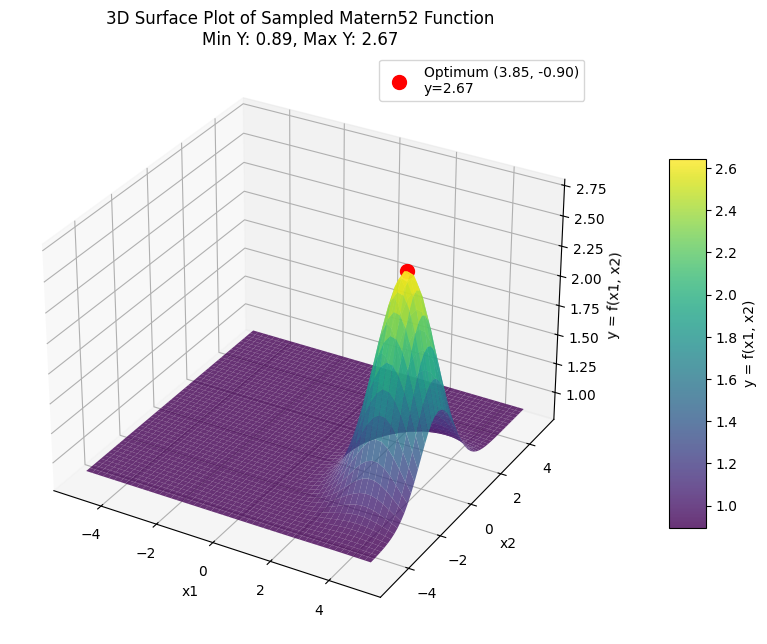

Plotting complete.


In [100]:
# === Imports ===

import matplotlib.cm as cm # For colormaps

# === Configuration ===
sampler_index_to_plot = 4  # 0:Ackley, 1:Poly, 2:NegAbs, 3:Gaussian, 4:Matern52
action_dimension = 2       # Set to 2 for 2D visualization
x_min, x_max = -5.0, 5.0   # Bounds for both x1 and x2 axes
num_points_per_dim = 50    # Reduced points for 2D grid (50x50 = 2500 total)
GPJAX_GRID_SIZE = 200      # Keep GPJax internal grid size (if needed by function_params_to_dict)


# === Sample Dictionary Definition (Crucial for 2D) ===
# Redefine or ensure this uses the current action_dimension=2
# The jnp.full shapes must match action_dimension=2
sample_dict = {'common': {
                   'type_index': sampler_index_to_plot,
                   'optimum_point': jnp.zeros(action_dimension), # Placeholder
                   'max_y': 0.0,
                   'min_y': 0.0,
                   'action_dim': action_dimension,
               },
               'specific': {
                   'ackley': { # Parameters are mostly scalar, OK for 2D
                       "a": 15.0, "b": 0.1, "c": 2 * np.pi,
                       'optimum_range_factor': 0.9, 'a_bounds': (15.0, 20.0),
                       'b_bounds': (0.1, 0.2), 'c_bounds': (2 * np.pi, 2 * np.pi),
                   },
                   'poly' :{ # Ensure arrays match action_dimension
                       'c': 10.0,
                       'weights': jnp.full((action_dimension,), 1.0, dtype=jnp.float64), # Use dim=2
                       'x_max': jnp.full((action_dimension,), 0.0, dtype=jnp.float64),   # Use dim=2
                       'degree': 2, 'optimum_range_factor': 0.9,
                       'c_bounds': (5.0, 20.0), 'weight_bounds': (0.5, 2.0),
                       'steepness_factor': 1.0, # Scalar steepness or per-dim? Assuming scalar now
                       'steep_min': 0.5, 'steep_max': 2.0,
                   },
                   'neg_abs': {}, # OK for 2D
                   'gaussian': { # Ensure arrays match action_dimension
                       'center': jnp.full((action_dimension,), 0.0, dtype=jnp.float64), # Use dim=2
                       'width': jnp.full((action_dimension,), 1.0, dtype=jnp.float64),  # Use dim=2
                       'amplitude': 1.0, 'baseline': 0.0, 'width_bounds': (0.5, 2.0),
                       'amplitude_bounds': (0.5, 2.0), 'baseline_bounds': (-1.0, 1.0),
                   },
                   'gpjax_matern52': { # Ensure arrays match action_dimension
                       'grid_size': GPJAX_GRID_SIZE,
                       'x_grid': jnp.full((GPJAX_GRID_SIZE,), jnp.nan, dtype=jnp.float64),
                       'y_grids': jnp.full((action_dimension, GPJAX_GRID_SIZE), jnp.nan, dtype=jnp.float64), # Use dim=2
                   },
                   # Add 'matern52' key if that's what your code uses
                   'matern52': { # Ensure arrays match action_dimension
                       'grid_size': GPJAX_GRID_SIZE,
                       'x_grid': jnp.full((GPJAX_GRID_SIZE,), jnp.nan, dtype=jnp.float64),
                       'y_grids': jnp.full((action_dimension, GPJAX_GRID_SIZE), jnp.nan, dtype=jnp.float64), # Use dim=2
                   },
               }
              }

# === Environment Parameters ===
# Ensure EnvParams receives the updated sample_dict and action_dim
# Note: You might need to pass other required args for EnvParams constructor
env_params = EnvParams(
    total_samples=5, # Example value
    max_batches=1, # Example value
    max_steps_in_episode=20, # Example value
    sampler_configs=sample_dict,
    action_dim=action_dimension, # Pass dim=2
    x_range=(x_min, x_max)     # Pass bounds
    # Add any other required parameters for EnvParams
)


# === Environment Parameters ===
env_params = EnvParams(
    total_samples=5, max_batches=1, max_steps_in_episode=20,
    sampler_configs=sample_dict, action_dim=action_dimension, x_range=(x_min, x_max)
)

# === Initialize Sampler ===
key = jax.random.key(66)
print(f"Initializing sampler for action_dim={action_dimension}...")
sampler_params = initialize_sampler(key, sampler_index_to_plot, action_dimension, env_params)
print("Initialization complete.")
print("--- Initialized Sampler Parameters (Common) ---")
print(sampler_params['common'])

# === Generate Data for 3D Plotting ===
# (This part is identical to the 2D version)
x1_coords = jnp.linspace(x_min, x_max, num_points_per_dim)
x2_coords = jnp.linspace(x_min, x_max, num_points_per_dim)
X1, X2 = jnp.meshgrid(x1_coords, x2_coords)
x_plot_2d = jnp.stack([X1.ravel(), X2.ravel()], axis=-1)
print(f"Shape of input points for vmap: {x_plot_2d.shape}")

# === Compute Y Values ===
# (This part is identical to the 2D version)
compute_single_y = lambda x: compute_y_sampler(x, sampler_params, env_params)
compute_single_y_jit = jax.jit(compute_single_y)
print("Computing Y values using vmap...")
y_plot_flat = jax.vmap(compute_single_y_jit)(x_plot_2d)
print("Computation complete.")
print(f"Shape of flat Y results: {y_plot_flat.shape}")
Y = y_plot_flat.reshape(X1.shape) # Reshape Y to 2D grid
print(f"Shape of reshaped Y grid: {Y.shape}")

# === Plotting (3D Surface) ===
print("Generating 3D plot...")
fig = plt.figure(figsize=(10, 8)) # Adjust figure size for 3D
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
# cmap options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'coolwarm', 'jet', etc.
surf = ax.plot_surface(X1, X2, Y, cmap=cm.viridis, # Use a colormap
                       linewidth=0.2,              # Line width for the wireframe
                       antialiased=True,           # Make it smoother
                       alpha=0.8)                  # Slightly transparent

# Add a color bar which maps values to colors
fig.colorbar(surf, shrink=0.6, aspect=10, label='y = f(x1, x2)', pad=0.1)

# Highlight Optimum
opt_xy = sampler_params["common"]['optimum_point'] # Shape (2,)
max_y = sampler_params["common"]['max_y']          # Scalar Z value for optimum
min_y = sampler_params["common"]['min_y']          # Scalar min value

# Plot optimum point as a 3D scatter point
ax.scatter(opt_xy[0], opt_xy[1], max_y, color='red', s=100, depthshade=True,
           label=f'Optimum ({opt_xy[0]:.2f}, {opt_xy[1]:.2f})\ny={max_y:.2f}')

# Add labels and title
# Get function name
func_names = {0: 'Ackley', 1: 'Polynomial', 2: 'NegAbs', 3: 'Gaussian', 4: 'Matern52'}
func_name = func_names.get(sampler_index_to_plot, f'Sampler {sampler_index_to_plot}')

ax.set_title(f'3D Surface Plot of Sampled {func_name} Function\nMin Y: {min_y:.2f}, Max Y: {max_y:.2f}')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y = f(x1, x2)')

# Adjust view angle if desired (optional)
# ax.view_init(elev=30, azim=-60) # Example: elevation 30, azimuth -60

ax.legend()
plt.show()
print("Plotting complete.")

In [ ]:
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt


config.update("jax_enable_x64", True)


with install_import_hook("gpjax", "beartype.beartype"):
    import gpjax as gpx


key = jr.key(123)



cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

In [ ]:
import gpjax as gpx

n = 100
noise = 0.3

key, subkey = jax.random.split(key)
x = jax.random.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x)
y = signal + jax.random.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)


xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 1)
ytest = f(xtest)

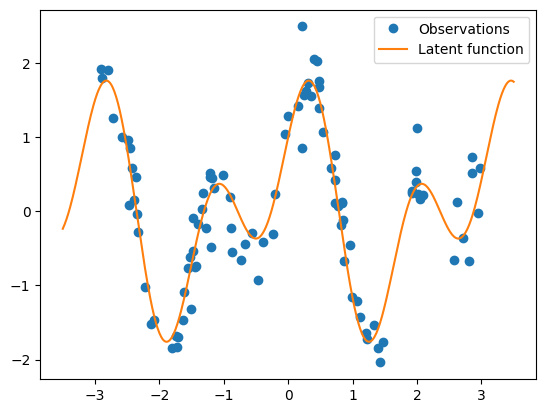

In [ ]:
fig, ax = plt.subplots()
ax.plot(x, y, "o", label="Observations", color=cols[0])
ax.plot(xtest, ytest, label="Latent function", color=cols[1])
ax.legend(loc="best")

In [ ]:
kernel = gpx.kernels.RBF()  # 1-dimensional input
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

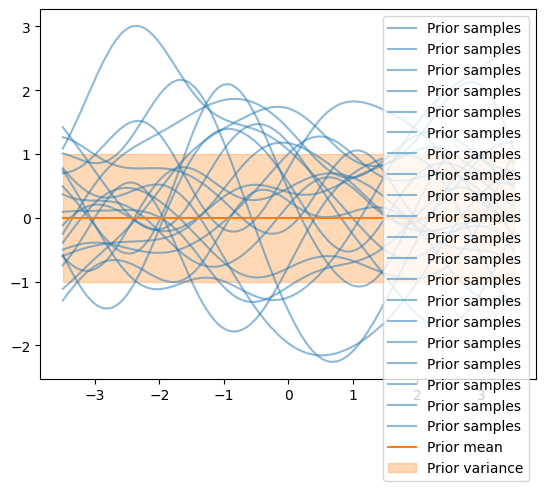

In [ ]:
prior_dist = prior.predict(xtest)

prior_mean = prior_dist.mean
prior_std = prior_dist.variance
samples = prior_dist.sample(key=key, sample_shape=(20,))


fig, ax = plt.subplots()
ax.plot(xtest, samples.T, alpha=0.5, color=cols[0], label="Prior samples")
ax.plot(xtest, prior_mean, color=cols[1], label="Prior mean")
ax.fill_between(
    xtest.flatten(),
    prior_mean - prior_std,
    prior_mean + prior_std,
    alpha=0.3,
    color=cols[1],
    label="Prior variance",
)
ax.legend(loc="best")
# ax = clean_legend(ax)

In [ ]:
likelihood = gpx.likelihoods.Gaussian(num_datapoints=D.n)
posterior = prior * likelihood

In [ ]:
opt_posterior, history = gpx.fit_scipy(
    model=posterior,
    # we use the negative mll as we are minimising
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=D,
)

print(-gpx.objectives.conjugate_mll(opt_posterior, D))

Optimization terminated successfully.
         Current function value: 55.469226
         Iterations: 12
         Function evaluations: 19
         Gradient evaluations: 19
55.46922647118374


In [ ]:
latent_dist = opt_posterior.predict(xtest, train_data=D)
predictive_dist = opt_posterior.likelihood(latent_dist)

predictive_mean = predictive_dist.mean
predictive_std = jnp.sqrt(predictive_dist.variance)

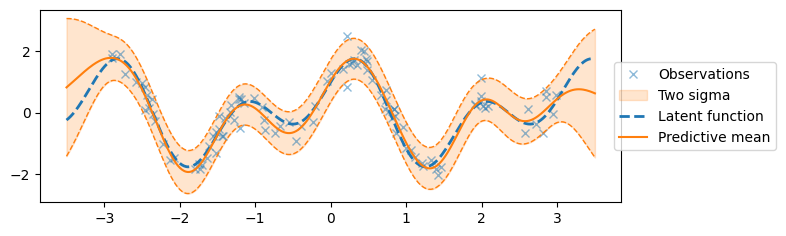

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 2.5))
ax.plot(x, y, "x", label="Observations", color=cols[0], alpha=0.5)
ax.fill_between(
    xtest.squeeze(),
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    alpha=0.2,
    label="Two sigma",
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_mean - 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_mean + 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest, ytest, label="Latent function", color=cols[0], linestyle="--", linewidth=2
)
ax.plot(xtest, predictive_mean, label="Predictive mean", color=cols[1])
ax.legend(loc="center left", bbox_to_anchor=(0.975, 0.5))